In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv("HX695A_Dataset.csv")

In [61]:
df.shape

(5907, 39)

In [62]:
df.dtypes

Record_ID                       object
Date                            object
Time                            object
Shift                           object
HX_ID                           object
Operator_ID                     object
Hot_Fluid                       object
Hot_Inlet_Temp_C               float64
Hot_Outlet_Temp_C              float64
Hot_Pressure_bar               float64
Hot_Flow_Rate_kg_hr            float64
Cold_Fluid                      object
Cold_Inlet_Temp_C              float64
Cold_Outlet_Temp_C             float64
Cold_Pressure_bar              float64
Cold_Flow_Rate_kg_hr           float64
Heat_Duty_kW                   float64
LMTD_C                         float64
U_Value_W_m2K                  float64
Reynolds_Number                  int64
Effectiveness_pct              float64
Thermal_Efficiency_pct         float64
Fouling_Factor_m2K_W           float64
Pressure_Drop_Shell_bar        float64
Pressure_Drop_Tube_bar         float64
Cooling_Water_Makeup_pct 

In [63]:
df.head() #Top 5 rows of the data

,Record_ID,Date,Time,Shift,HX_ID,Operator_ID,Hot_Fluid,Hot_Inlet_Temp_C,Hot_Outlet_Temp_C,Hot_Pressure_bar,...,Maintenance_Required,Alarm_Count,Sensor_Status,Equipment_Health_Score,Failure_Risk,Ambient_Temp_C,Relative_Humidity_pct,Electricity_Consumption_kWh,Energy_Loss_kW,Failure_Within_7Days
0,REC-00001,2023-01-01,00:00,A,HX-695-A,OP-010,Propylene,53.70,29.18,16.67,...,No,0,Warning,88.2,Low,20.27,62.9,40.31,1859.7,0
1,REC-00002,2023-01-01,03:00,A,HX-695-A,OP-003,Propylene,54.19,29.68,15.92,...,No,0,Normal,71.8,Medium,17.51,56.5,41.59,1868.1,0
2,REC-00003,2023-01-01,06:00,A,HX-695-A,OP-005,Propylene,53.26,29.78,16.78,...,No,0,Warning,73.3,Medium,16.33,58.9,41.43,1870.5,0
3,REC-00004,2023-01-01,09:00,B,HX-695-A,OP-001,Propylene,53.84,28.49,16.14,...,No,0,Warning,87.9,Low,17.01,63.0,45.26,1856.7,0
4,REC-00005,2023-01-01,12:00,B,HX-695-A,OP-004,Propylene,54.12,28.89,16.59,...,No,0,Normal,85.1,Low,18.21,64.8,48.21,1866.0,0


## Understanding data

In [6]:
df.isnull().sum().sort_values(ascending=False) #Missing Values

Equipment_Health_Score         187
Fouling_Factor_m2K_W           186
Hot_Outlet_Temp_C              181
Heat_Duty_kW                   179
Hot_Inlet_Temp_C               173
Electricity_Consumption_kWh    170
Cold_Flow_Rate_kg_hr           159
U_Value_W_m2K                  152
Hot_Fluid                        0
HX_ID                            0
Operator_ID                      0
Time                             0
Date                             0
Record_ID                        0
Shift                            0
Cold_Pressure_bar                0
Cold_Outlet_Temp_C               0
Cold_Inlet_Temp_C                0
Cold_Fluid                       0
LMTD_C                           0
Reynolds_Number                  0
Hot_Pressure_bar                 0
Hot_Flow_Rate_kg_hr              0
Thermal_Efficiency_pct           0
Effectiveness_pct                0
Pressure_Drop_Shell_bar          0
Pressure_Drop_Tube_bar           0
Days_Since_Cleaning              0
Last_Maintenance_Dat

In [7]:
print(df['Date'].min(), df['Date'].max())
df.describe()

2023-01-01 2024-12-31


,Hot_Inlet_Temp_C,Hot_Outlet_Temp_C,Hot_Pressure_bar,Hot_Flow_Rate_kg_hr,Cold_Inlet_Temp_C,Cold_Outlet_Temp_C,Cold_Pressure_bar,Cold_Flow_Rate_kg_hr,Heat_Duty_kW,LMTD_C,...,Cooling_Water_Makeup_pct,Operating_Hours,Days_Since_Cleaning,Alarm_Count,Equipment_Health_Score,Ambient_Temp_C,Relative_Humidity_pct,Electricity_Consumption_kWh,Energy_Loss_kW,Failure_Within_7Days
count,5734.000000,5726.000000,5907.000000,5907.000000,5907.000000,5907.000000,5907.000000,5748.000000,5728.000000,5907.000000,...,5907.000000,5907.000000,5907.000000,5907.000000,5720.000000,5907.000000,5907.000000,5737.000000,5907.000000,5907.000000
mean,53.984034,33.218896,16.487369,9800.784899,25.845622,32.545099,3.400261,17792.027749,138.497259,13.158923,...,2.169162,779.502844,32.479900,0.465211,63.079318,26.991774,54.982038,42.893871,1891.001253,0.114271
std,1.592302,2.185118,0.395545,353.427506,2.719047,2.187852,0.149332,500.691471,17.036924,1.758062,...,0.316572,478.074842,19.919621,0.956522,21.873875,6.134477,15.010288,4.007674,17.328124,0.318167
min,48.360000,26.400000,15.030000,8432.600000,19.200000,26.680000,2.890000,15853.500000,87.100000,8.360000,...,0.980000,0.000000,0.000000,0.000000,5.000000,13.800000,25.000000,28.100000,1830.700000,0.000000
25%,52.920000,31.560000,16.210000,9566.750000,23.520000,30.720000,3.300000,17459.300000,126.300000,11.890000,...,1.960000,380.500000,15.855000,0.000000,46.800000,21.260000,41.600000,40.260000,1878.500000,0.000000
50%,54.000000,33.235000,16.490000,9804.100000,25.850000,32.610000,3.400000,17795.350000,138.300000,13.040000,...,2.170000,754.700000,31.450000,0.000000,64.200000,26.970000,54.800000,42.890000,1891.200000,0.000000
75%,55.020000,34.897500,16.760000,10035.550000,28.140000,34.320000,3.500000,18123.400000,150.900000,14.380000,...,2.380000,1140.700000,47.530000,1.000000,81.300000,32.800000,68.300000,45.560000,1903.300000,0.000000
max,59.340000,39.740000,17.960000,11314.400000,33.230000,38.030000,3.920000,19892.700000,196.000000,18.830000,...,3.310000,2297.200000,95.720000,16.000000,100.000000,40.170000,92.900000,56.540000,1943.600000,1.000000


In [8]:
df['Failure_Within_7Days'].value_counts(normalize=True)

Failure_Within_7Days
0    0.885729
1    0.114271
Name: proportion, dtype: float64

In [9]:
df[['Fouling_Factor_m2K_W', 'Thermal_Efficiency_pct', 'U_Value_W_m2K', 
    'Operating_Hours', 'Pressure_Drop_Tube_bar']].corr()

,Fouling_Factor_m2K_W,Thermal_Efficiency_pct,U_Value_W_m2K,Operating_Hours,Pressure_Drop_Tube_bar
Fouling_Factor_m2K_W,1.000000,-0.911545,-0.991362,0.998017,0.808018
Thermal_Efficiency_pct,-0.911545,1.000000,0.917862,-0.908187,-0.727461
U_Value_W_m2K,-0.991362,0.917862,1.000000,-0.987020,-0.790535
Operating_Hours,0.998017,-0.908187,-0.987020,1.000000,0.796905
Pressure_Drop_Tube_bar,0.808018,-0.727461,-0.790535,0.796905,1.000000


In [10]:
df.duplicated().sum()

np.int64(59)

## Clean the Data

In [11]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.sort_values('Datetime').reset_index(drop=True)

In [12]:
before = len(df)
df = df.drop_duplicates(subset='Record_ID', keep='first').reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows")

Removed 59 duplicate rows


In [13]:
df['Sensor_Fault_Flag'] = (df['Sensor_Status'] == 'Fault').astype(int)
df['Sensor_Status'].value_counts()

Sensor_Status
Normal     4966
Warning     706
Fault       176
Name: count, dtype: int64

In [14]:
sensor_cols = ['Hot_Inlet_Temp_C', 'Hot_Outlet_Temp_C', 'Cold_Flow_Rate_kg_hr',
               'Heat_Duty_kW', 'Fouling_Factor_m2K_W', 'Equipment_Health_Score',
               'Electricity_Consumption_kWh', 'U_Value_W_m2K']

df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both')

# confirm no more missing values
df[sensor_cols].isnull().sum()

Hot_Inlet_Temp_C               0
Hot_Outlet_Temp_C              0
Cold_Flow_Rate_kg_hr           0
Heat_Duty_kW                   0
Fouling_Factor_m2K_W           0
Equipment_Health_Score         0
Electricity_Consumption_kWh    0
U_Value_W_m2K                  0
dtype: int64

In [15]:
print(df.shape)
df.isnull().sum().sum()   # should be 0 now

(5848, 41)


np.int64(0)

## EDA

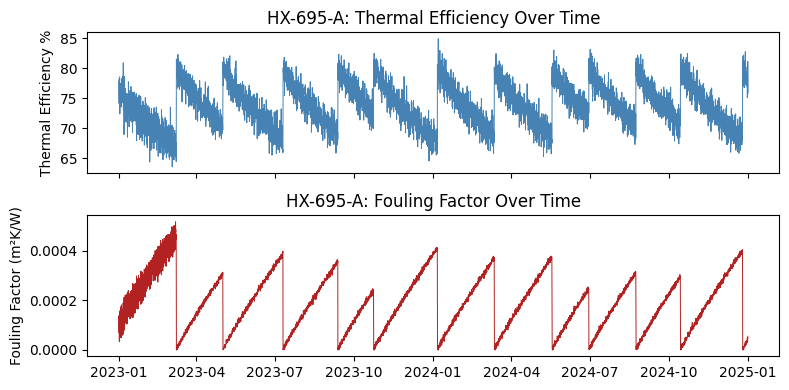

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

axes[0].plot(df['Datetime'], df['Thermal_Efficiency_pct'], linewidth=0.7, color='steelblue')
axes[0].set_ylabel('Thermal Efficiency %')
axes[0].set_title('HX-695-A: Thermal Efficiency Over Time')

axes[1].plot(df['Datetime'], df['Fouling_Factor_m2K_W'], linewidth=0.7, color='firebrick')
axes[1].set_ylabel('Fouling Factor (m²K/W)')
axes[1].set_title('HX-695-A: Fouling Factor Over Time')

plt.tight_layout()
plt.show()

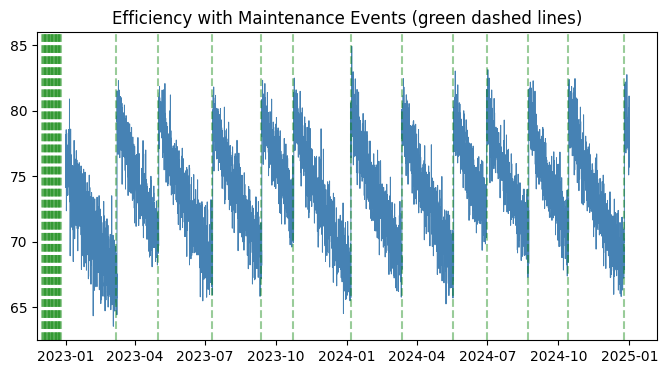

In [17]:
maint_dates = pd.to_datetime(df['Last_Maintenance_Date'].unique())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Datetime'], df['Thermal_Efficiency_pct'], linewidth=0.7, color='steelblue')
for md in maint_dates:
    ax.axvline(md, color='green', linestyle='--', alpha=0.4)
ax.set_title('Efficiency with Maintenance Events (green dashed lines)')
plt.show()

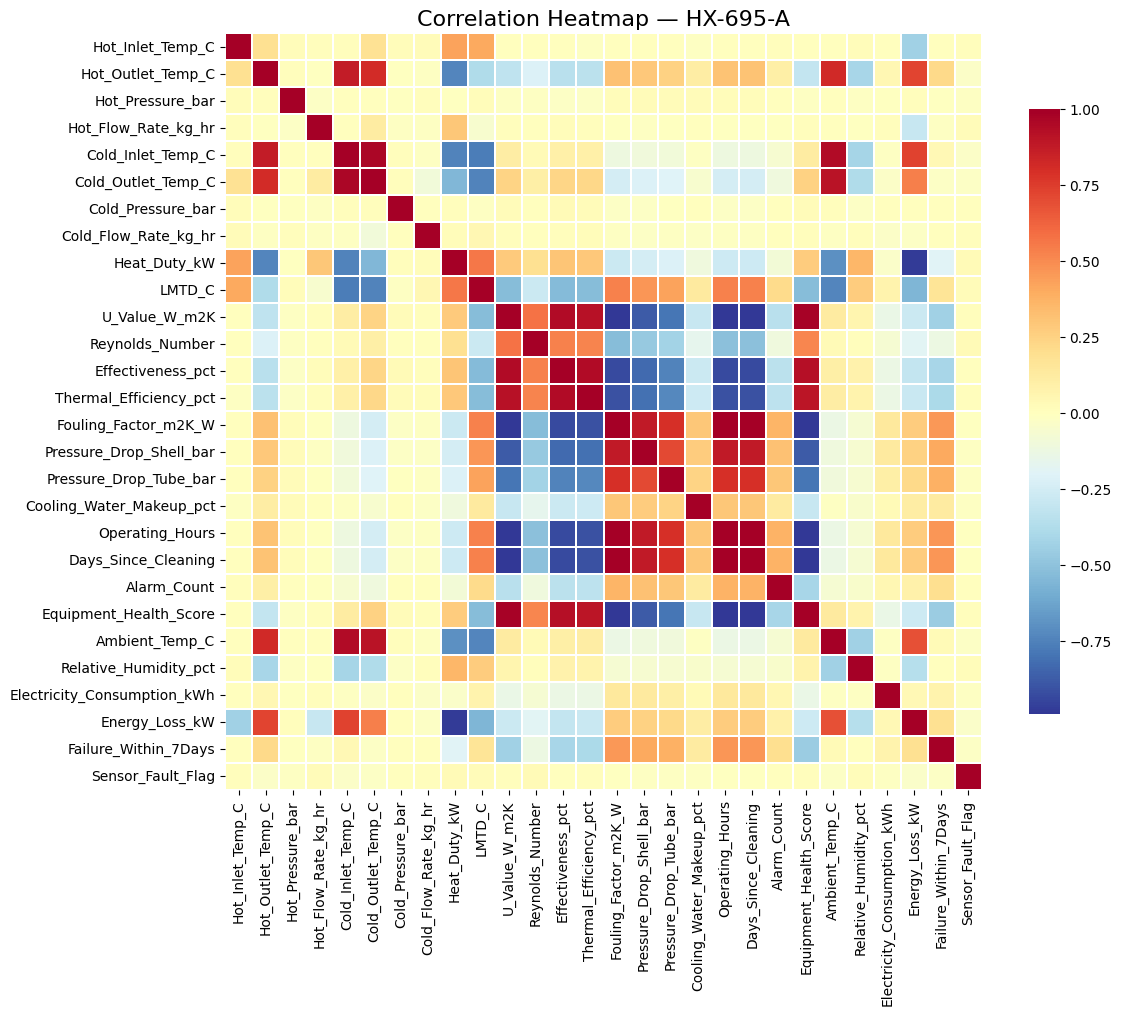

In [18]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(),cmap='RdYlBu_r',center=0,linewidths=0.3, square=True,cbar_kws={'shrink':0.8})
plt.title('Correlation Heatmap — HX-695-A', fontsize=16)
plt.tight_layout()
plt.show()

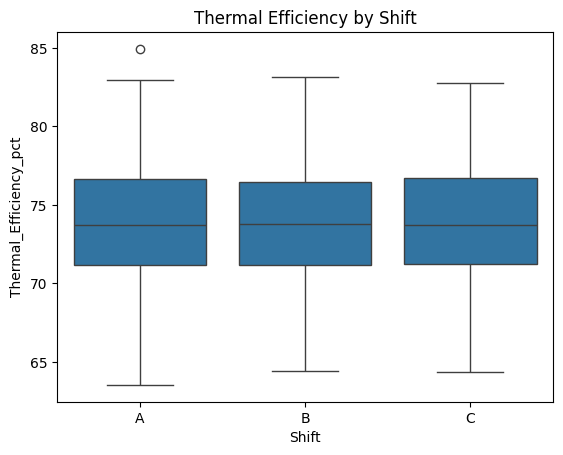

In [19]:
sns.boxplot(data=df, x='Shift', y='Thermal_Efficiency_pct')
plt.title('Thermal Efficiency by Shift')
plt.show()

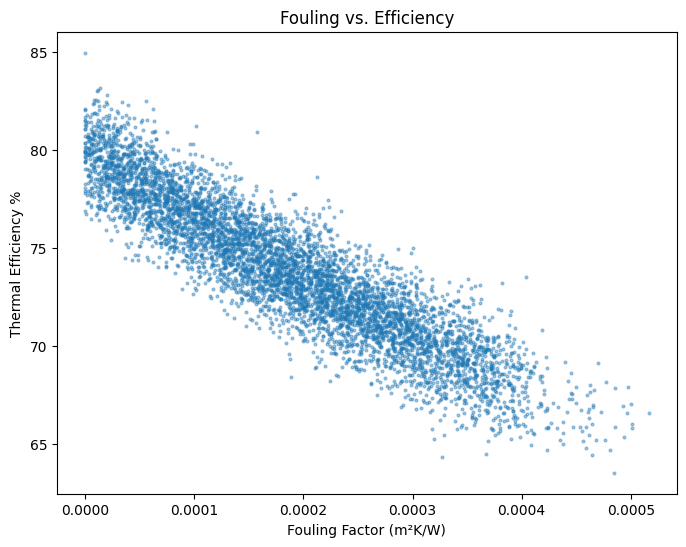

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Fouling_Factor_m2K_W'], df['Thermal_Efficiency_pct'], s=4, alpha=0.4)
plt.xlabel('Fouling Factor (m²K/W)')
plt.ylabel('Thermal Efficiency %')
plt.title('Fouling vs. Efficiency')
plt.show()

## Feature Engineering

In [21]:
df = df.sort_values('Datetime').reset_index(drop=True)

window = 24  # 24 readings x 3-hour interval = 72 hours

df['Efficiency_Roll72h'] = df['Thermal_Efficiency_pct'].rolling(window, min_periods=1).mean()
df['Fouling_Roll72h'] = df['Fouling_Factor_m2K_W'].rolling(window, min_periods=1).mean()
df['PressureDrop_Roll72h'] = df['Pressure_Drop_Tube_bar'].rolling(window, min_periods=1).mean()

In [22]:
df.shape

(5848, 44)

In [23]:
df['Efficiency_Change'] = df['Thermal_Efficiency_pct'].diff()
df['Fouling_Change'] = df['Fouling_Factor_m2K_W'].diff()
df['PressureDrop_Change'] = df['Pressure_Drop_Tube_bar'].diff()

# slope over the rolling window - trend direction, not just noise
df['Efficiency_Slope72h'] = df['Thermal_Efficiency_pct'].diff(window) / window

In [24]:
df['Month'] = df['Datetime'].dt.month
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [25]:
df['Days_x_Ambient'] = df['Days_Since_Cleaning'] * df['Ambient_Temp_C']

In [26]:
df = df.iloc[window:].reset_index(drop=True)
print(df.shape)
df[['Efficiency_Roll72h', 'Fouling_Change', 'Efficiency_Slope72h', 'Month_sin']].head()

(5824, 52)


,Efficiency_Roll72h,Fouling_Change,Efficiency_Slope72h,Month_sin
0,75.515417,0.000068,-0.192917,0.5
1,75.507083,-0.000132,-0.008333,0.5
2,75.547083,0.000072,0.040000,0.5
3,75.527917,-0.000034,-0.019167,0.5
4,75.379167,0.000052,-0.148750,0.5


## Classification Model

In [27]:
feature_cols = [
    'Hot_Inlet_Temp_C', 'Hot_Outlet_Temp_C', 'Cold_Inlet_Temp_C', 'Cold_Outlet_Temp_C',
    'Fouling_Factor_m2K_W', 'U_Value_W_m2K', 'Thermal_Efficiency_pct', 'Effectiveness_pct',
    'Pressure_Drop_Tube_bar', 'Pressure_Drop_Shell_bar', 'Operating_Hours', 'Days_Since_Cleaning',
    'Alarm_Count', 'Equipment_Health_Score', 'Ambient_Temp_C',
    'Efficiency_Roll72h', 'Fouling_Roll72h', 'PressureDrop_Roll72h',
    'Efficiency_Change', 'Fouling_Change', 'PressureDrop_Change', 'Efficiency_Slope72h',
    'Month_sin', 'Month_cos', 'Days_x_Ambient'
]

X = df[feature_cols]
y = df['Failure_Within_7Days']

In [28]:
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train failure rate: {y_train.mean():.3f}, Test failure rate: {y_test.mean():.3f}")

Train: (4659, 25), Test: (1165, 25)
Train failure rate: 0.108, Test failure rate: 0.144


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [30]:
# from sklearn.ensemble import RandomForestClassifier

# rf_model = RandomForestClassifier(
#     n_estimators=200, max_depth=8, class_weight='balanced', random_state=42
# )
# rf_model.fit(X_train, y_train)

# y_pred_rf = rf_model.predict(X_test)
# y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# instead of default 0.5 cutoff, lower the threshold to catch more real failures
y_pred_rf = (y_proba_rf >= 0.15).astype(int)

In [31]:
from sklearn.metrics import classification_report

print("Logistic Regression:")
print(classification_report(y_test, y_pred_log))

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       997
           1       0.42      0.98      0.59       168

    accuracy                           0.81      1165
   macro avg       0.71      0.88      0.73      1165
weighted avg       0.91      0.81      0.83      1165

Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92       997
           1       0.52      0.55      0.53       168

    accuracy                           0.86      1165
   macro avg       0.72      0.73      0.73      1165
weighted avg       0.86      0.86      0.86      1165



In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix (Logistic Regression):")
print(cm)

Confusion Matrix (Logistic Regression):
[[774 223]
 [  4 164]]


In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm)

Confusion Matrix (Random Forest):
[[911  86]
 [ 76  92]]


In [34]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, y_pred_rf)
accuracy2 = accuracy_score(y_test, y_pred_log)

print(f"Random Forest Accuracy: {accuracy1:.4f}")
print(f"Accuracy: {accuracy1*100:.2f}%")

print(f"Logistic Regression Accuracy: {accuracy2:.4f}")
print(f"Accuracy: {accuracy2*100:.2f}%")

Random Forest Accuracy: 0.8609
Accuracy: 86.09%
Logistic Regression Accuracy: 0.8052
Accuracy: 80.52%


In [35]:
final_classifier = log_model
final_scaler = scaler  # needed since Logistic Regression uses scaled features

print("Final classifier: Logistic Regression")
print(f"Recall (catch real failures): {0.98}")
print(f"Precision (false alarm rate): {1 - 0.42:.0%} of alerts are false alarms")

Final classifier: Logistic Regression
Recall (catch real failures): 0.98
Precision (false alarm rate): 58% of alerts are false alarms


## Regression Model

In [36]:
reg_feature_cols = [
    'Hot_Inlet_Temp_C', 'Cold_Inlet_Temp_C', 'Cold_Outlet_Temp_C',
    'U_Value_W_m2K', 'Effectiveness_pct',
    'Pressure_Drop_Tube_bar', 'Pressure_Drop_Shell_bar', 'Operating_Hours', 'Days_Since_Cleaning',
    'Alarm_Count', 'Ambient_Temp_C',
    'Fouling_Roll72h', 'PressureDrop_Roll72h',
    'Fouling_Change', 'PressureDrop_Change',
    'Month_sin', 'Month_cos', 'Days_x_Ambient'
]
# Note: Fouling_Factor_m2K_W and Efficiency_Roll72h are deliberately excluded —
# they're too directly derived from/correlated with the target itself (0.91+), which would be leakage

X_reg = df[reg_feature_cols]
y_reg = df['Thermal_Efficiency_pct']

X_reg_train, X_reg_test = X_reg.iloc[:split_idx], X_reg.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lin_model = LinearRegression()
lin_model.fit(X_reg_train, y_reg_train)
y_pred_lin = lin_model.predict(X_reg_test)

print("Linear Regression:")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_lin):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_lin)):.2f}")
print(f"R²: {r2_score(y_reg_test, y_pred_lin):.3f}")

Linear Regression:
MAE: 0.91
RMSE: 1.13
R²: 0.898


In [38]:
from sklearn.ensemble import RandomForestRegressor

# max_depth=6 keeps the trees simple enough that they don't just memorize the
# training data (we tested a few depths -- 6 gave the best train/test balance)
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42)
rf_reg.fit(X_reg_train, y_reg_train)
y_pred_rf_reg = rf_reg.predict(X_reg_test)

print("Random Forest Regressor:")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_rf_reg):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg)):.2f}")
print(f"R²: {r2_score(y_reg_test, y_pred_rf_reg):.3f}")
print(f"Train R²: {r2_score(y_reg_train, rf_reg.predict(X_reg_train)):.3f}  (close to test R² = not overfitting)")

Random Forest Regressor:
MAE: 0.92
RMSE: 1.14
R²: 0.896
Train R²: 0.915  (close to test R² = not overfitting)


### Why Linear Regression is risky to deploy

Linear Regression fits a straight line and has no concept of "physically impossible". If someone enters values that are far outside what the model was trained on (e.g. testing a long-overdue cleaning in the What-If tool), the straight line just keeps going — and can predict things like 500% efficiency, which obviously can't happen in real life.

Random Forest works differently: it predicts by averaging values it actually saw during training, so it can never output something wildly outside the training range, even on weird inputs. That makes it a lot safer to put behind a dashboard that other people will type numbers into.

Quick test to prove it:

In [39]:
# Simulate an operator entering a realistic-looking but extreme value in the What-If tool
# (say, the exchanger hasn't been cleaned in 250 days instead of the usual ~30)

extreme_case = X_reg_test.iloc[[0]].copy()
extreme_case['Days_Since_Cleaning'] = 250
extreme_case['Days_x_Ambient'] = 250 * extreme_case['Ambient_Temp_C']

lin_extreme = lin_model.predict(extreme_case)[0]
rf_extreme = rf_reg.predict(extreme_case)[0]

print(f"Linear Regression predicts:  {lin_extreme:.1f}% efficiency  <-- impossible, model is extrapolating")
print(f"Random Forest predicts:      {rf_extreme:.1f}% efficiency  <-- stays realistic")

Linear Regression predicts:  570.1% efficiency  <-- impossible, model is extrapolating
Random Forest predicts:      73.3% efficiency  <-- stays realistic


Linear Regression blows way past 100% on that input, while Random Forest stays in a realistic range even though it never saw exactly this combination before. Accuracy-wise the two models are basically tied (see MAE/RMSE/R² above), so there's no real trade-off — **Random Forest is the safer choice to deploy.**

In [40]:
# Random Forest matches Linear Regression on accuracy but can't produce impossible values,
# so we use it as the model that actually gets deployed to the dashboard.

final_regressor = rf_reg

def clip_efficiency(value):
    """Extra safety net: physically, efficiency can't be below 0% or above 100%."""
    return max(0, min(100, value))

y_pred_final = [clip_efficiency(p) for p in final_regressor.predict(X_reg_test)]

print("Final regression model: Random Forest Regressor (+ 0-100% safety clip)")

Final regression model: Random Forest Regressor (+ 0-100% safety clip)


The coefficients below are just to understand *which factors* Linear Regression leaned on most — they're not from the model we're actually deploying.

In [41]:
coef_df = pd.DataFrame({
    'Feature': reg_feature_cols,
    'Coefficient': lin_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df)

                    Feature  Coefficient
11          Fouling_Roll72h -1516.890040
13           Fouling_Change  -728.842837
8       Days_Since_Cleaning     2.359436
12     PressureDrop_Roll72h     0.770737
4         Effectiveness_pct     0.738304
6   Pressure_Drop_Shell_bar     0.545046
14      PressureDrop_Change     0.226405
5    Pressure_Drop_Tube_bar    -0.186916
2        Cold_Outlet_Temp_C     0.178142
1         Cold_Inlet_Temp_C    -0.126545
7           Operating_Hours    -0.098502
0          Hot_Inlet_Temp_C    -0.067729
16                Month_cos    -0.033244
9               Alarm_Count    -0.017881
15                Month_sin    -0.016366
3             U_Value_W_m2K     0.010827
10           Ambient_Temp_C    -0.004148
17           Days_x_Ambient    -0.000025


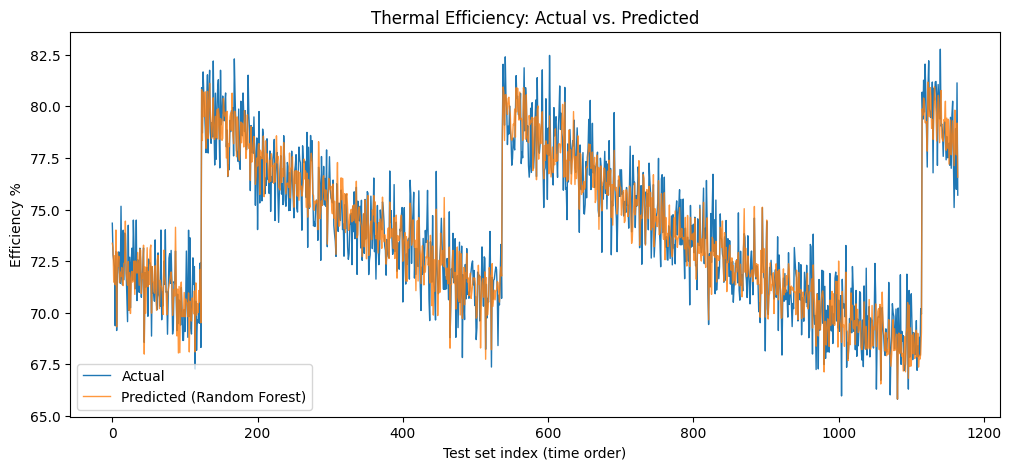

In [42]:
import matplotlib.pyplot as plt

y_pred_final_test = final_regressor.predict(X_reg_test)

plt.figure(figsize=(12, 5))
plt.plot(y_reg_test.values, label='Actual', linewidth=1)
plt.plot(y_pred_final_test, label='Predicted (Random Forest)', linewidth=1, alpha=0.8)
plt.legend()
plt.title('Thermal Efficiency: Actual vs. Predicted')
plt.ylabel('Efficiency %')
plt.xlabel('Test set index (time order)')
plt.show()

In [43]:
results_df = pd.DataFrame({
    'Datetime': df['Datetime'].iloc[split_idx:].values,
    'Actual_Efficiency': y_reg_test.values,
    'Predicted_Efficiency': [clip_efficiency(p) for p in final_regressor.predict(X_reg_test)],
    'Failure_Probability': log_model.predict_proba(X_test_scaled)[:, 1],
    'Actual_Failure_Within_7Days': y_test.values,
})
results_df.head(10)

,Datetime,Actual_Efficiency,Predicted_Efficiency,Failure_Probability,Actual_Failure_Within_7Days
0,2024-08-08 09:00:00,74.34,73.364565,0.634438,0
1,2024-08-08 12:00:00,72.82,73.154751,0.629648,0
2,2024-08-08 15:00:00,72.50,71.485285,0.545675,0
3,2024-08-08 18:00:00,72.22,72.755993,0.654074,0
4,2024-08-08 21:00:00,69.37,71.358929,0.756062,0
5,2024-08-09 00:00:00,72.97,74.009268,0.743853,0
6,2024-08-09 03:00:00,69.14,69.316944,0.572465,0
7,2024-08-09 06:00:00,71.55,72.935644,0.688972,0
8,2024-08-09 09:00:00,72.52,72.264049,0.660268,0
9,2024-08-09 12:00:00,72.95,72.735275,0.581042,0


In [44]:
recent_slope = df['Efficiency_Slope72h'].iloc[-1]  # % change per 3-hour reading
current_efficiency = df['Thermal_Efficiency_pct'].iloc[-1]
threshold = 58.0

if recent_slope < 0:
    readings_to_threshold = (current_efficiency - threshold) / abs(recent_slope)
    hours_to_threshold = readings_to_threshold * 3  # 3-hour intervals
    days_to_threshold = hours_to_threshold / 24
    print(f"Current efficiency: {current_efficiency:.1f}%")
    print(f"Estimated days until efficiency crosses {threshold}%: {days_to_threshold:.1f} days")
else:
    print("Efficiency is stable or improving — no near-term threshold crossing predicted")

Current efficiency: 75.7%
Estimated days until efficiency crosses 58.0%: 7.5 days


In [45]:
def risk_label(prob):
    if prob >= 0.6:
        return "🔴 High — schedule cleaning soon"
    elif prob >= 0.3:
        return "🟡 Medium — monitor closely"
    else:
        return "🟢 Low — normal operation"

results_df['Risk_Level'] = results_df['Failure_Probability'].apply(risk_label)
results_df[['Datetime', 'Actual_Efficiency', 'Failure_Probability', 'Risk_Level']].tail(15)

,Datetime,Actual_Efficiency,Failure_Probability,Risk_Level
1150,2024-12-30 03:00:00,77.51,0.004122,🟢 Low — normal operation
1151,2024-12-30 06:00:00,77.53,0.002490,🟢 Low — normal operation
1152,2024-12-30 09:00:00,78.22,0.003523,🟢 Low — normal operation
1153,2024-12-30 12:00:00,77.15,0.006837,🟢 Low — normal operation
1154,2024-12-30 15:00:00,79.47,0.003681,🟢 Low — normal operation
1155,2024-12-30 18:00:00,77.00,0.005180,🟢 Low — normal operation
1156,2024-12-30 21:00:00,79.59,0.004628,🟢 Low — normal operation
1157,2024-12-31 00:00:00,80.25,0.004735,🟢 Low — normal operation
1158,2024-12-31 03:00:00,77.40,0.004385,🟢 Low — normal operation
1159,2024-12-31 06:00:00,75.10,0.002441,🟢 Low — normal operation


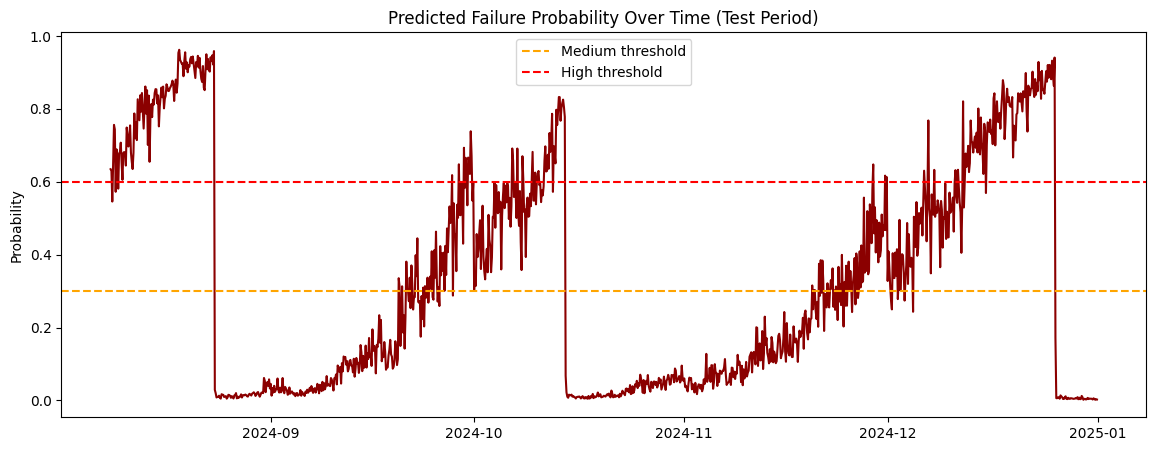

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(results_df['Datetime'], results_df['Failure_Probability'], color='darkred')
plt.axhline(0.3, color='orange', linestyle='--', label='Medium threshold')
plt.axhline(0.6, color='red', linestyle='--', label='High threshold')
plt.title('Predicted Failure Probability Over Time (Test Period)')
plt.ylabel('Probability')
plt.legend()
plt.show()

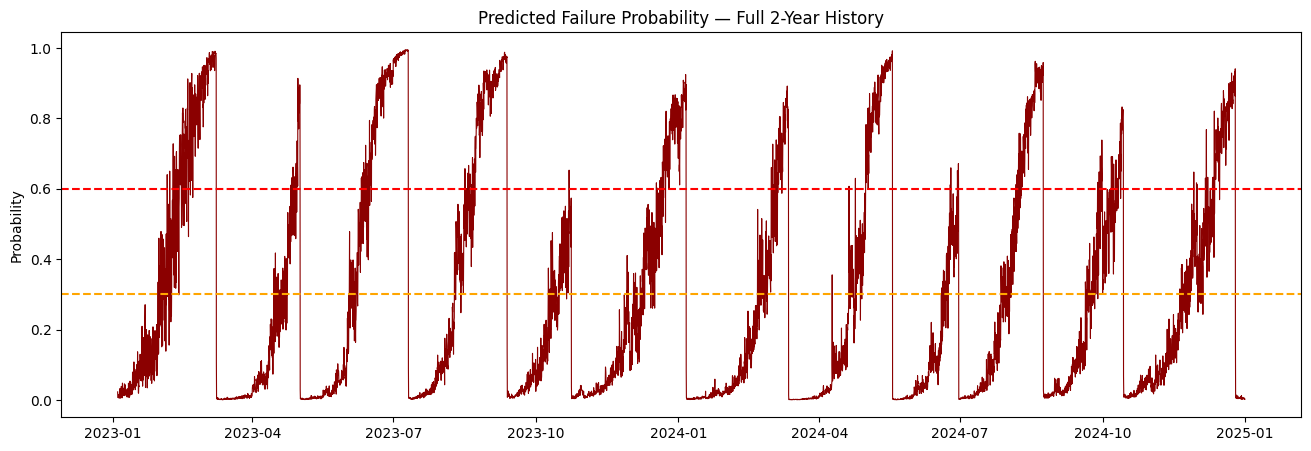

In [47]:
full_proba = log_model.predict_proba(scaler.transform(X))[:, 1]

plt.figure(figsize=(16, 5))
plt.plot(df['Datetime'], full_proba, color='darkred', linewidth=0.8)
plt.axhline(0.3, color='orange', linestyle='--')
plt.axhline(0.6, color='red', linestyle='--')
plt.title('Predicted Failure Probability — Full 2-Year History')
plt.ylabel('Probability')
plt.show()

## Safe Prediction Function (for the What-If dashboard)

One function that the dashboard can call. It uses the bounded Random Forest for efficiency and Logistic Regression for failure risk, and it tells you plainly if you've typed in values the model has never seen — instead of quietly returning something like "140%".

In [48]:
def predict_maintenance(inputs):
    """
    inputs: dict of sensor readings, using the same column names as the training data
    (e.g. 'Hot_Inlet_Temp_C', 'Days_Since_Cleaning', 'Fouling_Roll72h', ...)
    """

    # 1. Predicted efficiency -- Random Forest, can't go outside a realistic range
    reg_row = pd.DataFrame([[inputs[c] for c in reg_feature_cols]], columns=reg_feature_cols)
    efficiency = clip_efficiency(final_regressor.predict(reg_row)[0])

    # 2. Predicted failure probability -- Logistic Regression, already 0-100% by design
    clf_row = pd.DataFrame([[inputs[c] for c in feature_cols]], columns=feature_cols)
    clf_row_scaled = scaler.transform(clf_row)
    failure_prob = log_model.predict_proba(clf_row_scaled)[0, 1] * 100

    # 3. Check if any input is outside what the model actually saw in training
    out_of_range = [
        c for c in reg_feature_cols
        if inputs[c] < X_reg_train[c].min() or inputs[c] > X_reg_train[c].max()
    ]

    return {
        "predicted_efficiency_pct": round(efficiency, 1),
        "predicted_failure_probability_pct": round(failure_prob, 1),
        "out_of_range_inputs": out_of_range,
    }

In [49]:
# same overdue-cleaning scenario as before, run through the actual deployment function

sample_input = X_reg_test.iloc[0].to_dict()
sample_input.update({c: df[c].iloc[0] for c in feature_cols if c not in sample_input})
sample_input['Days_Since_Cleaning'] = 250
sample_input['Days_x_Ambient'] = 250 * sample_input['Ambient_Temp_C']

predict_maintenance(sample_input)

{'predicted_efficiency_pct': np.float64(73.3),
 'predicted_failure_probability_pct': np.float64(100.0),
 'out_of_range_inputs': ['Days_Since_Cleaning', 'Days_x_Ambient']}